<a href="https://colab.research.google.com/github/Binghui5728/SDG6-AI-midterm/blob/main/SDG6_AI_midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('water_potability.csv')
display(df.head())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### 檢查缺失值

In [5]:
# 檢查每個欄位的缺失值數量
missing_values = df.isnull().sum()
display(missing_values)

# 檢查每個欄位的缺失值百分比
missing_percentage = (df.isnull().sum() / len(df)) * 100
display(missing_percentage.sort_values(ascending=False))

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


,0
Sulfate,23.840049
ph,14.987790
Trihalomethanes,4.945055
Hardness,0.000000
Chloramines,0.000000
Solids,0.000000
Conductivity,0.000000
Organic_carbon,0.000000
Turbidity,0.000000
Potability,0.000000


### 處理缺失值

In [6]:
# 使用每個欄位的平均值來填補缺失值
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())

# 再次檢查缺失值，確認是否已全部填補
print("處理缺失值後的缺失值數量：")
display(df.isnull().sum())

處理缺失值後的缺失值數量：


,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


### 異常值檢測 (Outlier Detection)

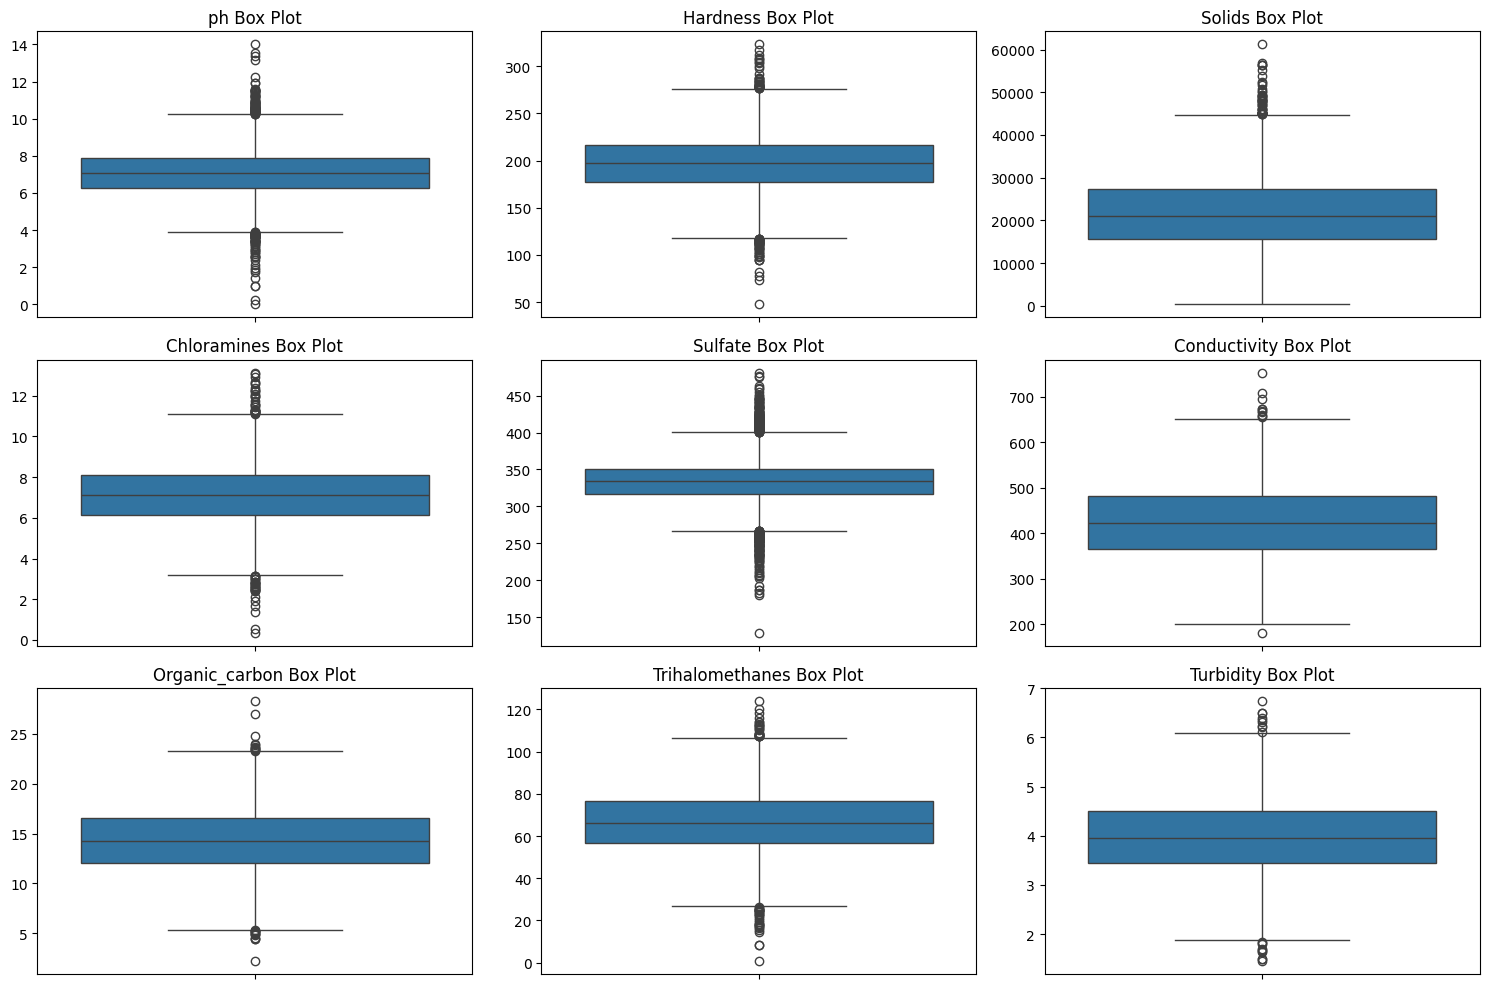

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 選擇數值型特徵進行異常值檢測 (排除目標變數 'Potability')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('Potability')

# 繪製每個數值型特徵的箱形圖
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # 假設最多9個數值型特徵，根據實際情況調整
    sns.boxplot(y=df[col])
    plt.title(f'{col} Box Plot')
    plt.ylabel('')
plt.tight_layout()
plt.show()

從箱形圖中，我們可以觀察到一些特徵存在異常值。接下來，我們可以根據這些視覺化結果來決定如何處理異常值。常見的方法包括：

*   **移除 (Removal)**: 直接刪除含有異常值的觀測值。
*   **蓋帽 (Capping)**: 將異常值替換為某個上限或下限值 (例如：99百分位數或1百分位數)。
*   **轉換 (Transformation)**: 使用對數轉換等方法來減少異常值的影響。

您希望採用哪種方法來處理異常值呢？或者您想進一步了解某個特定欄位的異常值情況嗎？

### 處理異常值 (蓋帽法 Capping)

異常值已使用1%和99%百分位數進行蓋帽處理。


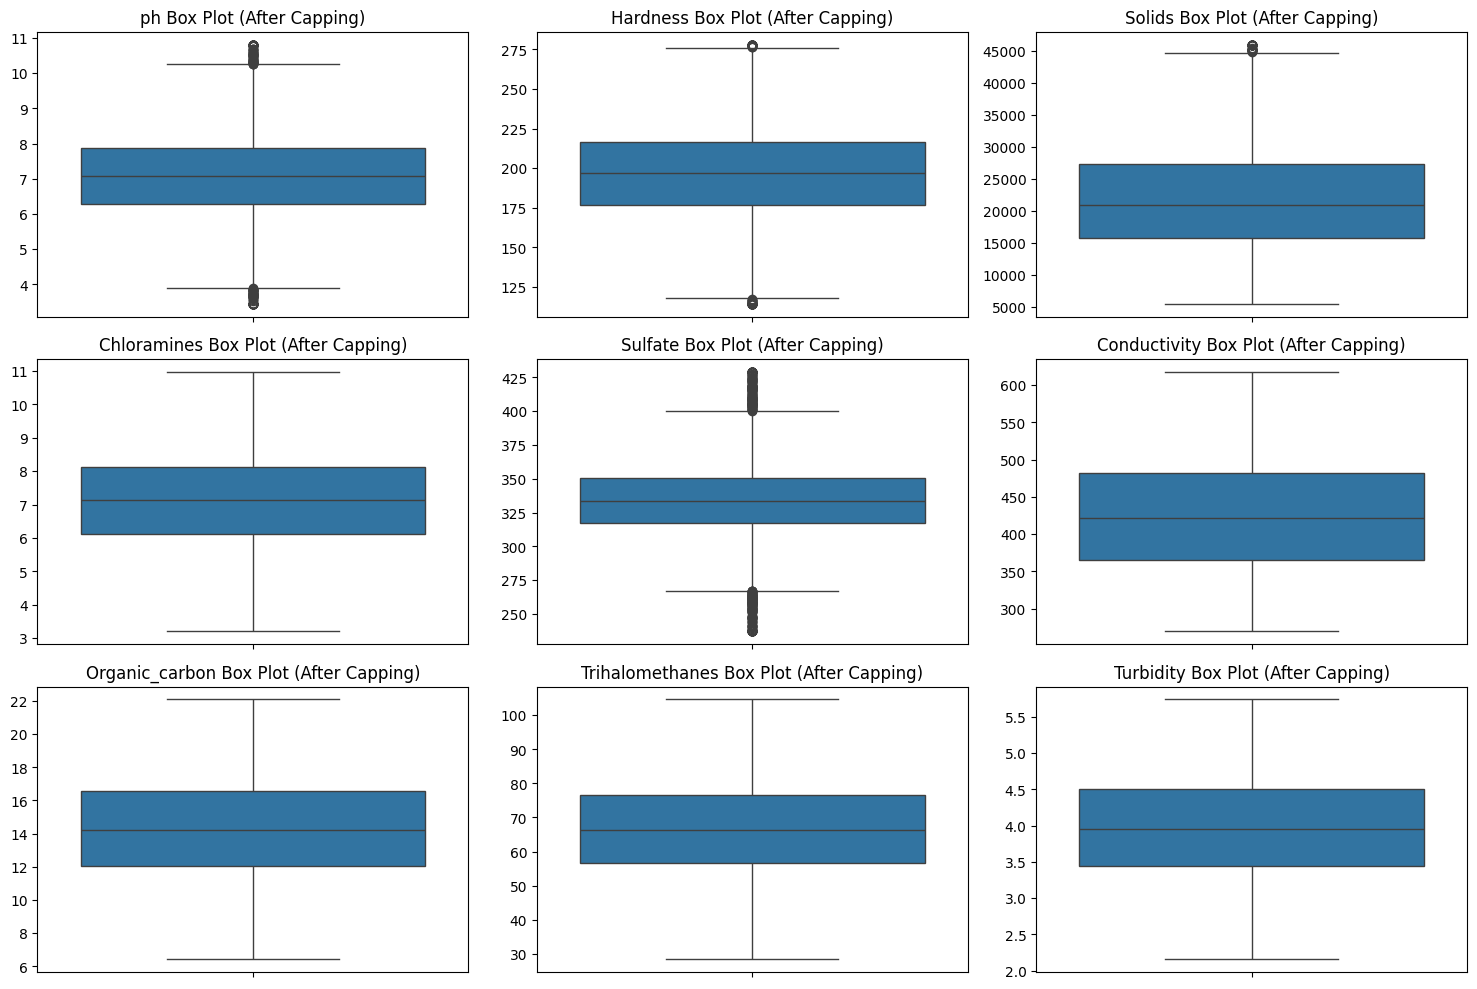

In [8]:
# 再次選擇數值型特徵進行處理 (排除目標變數 'Potability')
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols.remove('Potability')

# 對每個數值型特徵應用蓋帽法
for col in numerical_cols:
    Q1 = df[col].quantile(0.01) # 1st percentile
    Q99 = df[col].quantile(0.99) # 99th percentile

    # 將低於Q1的值替換為Q1，將高於Q99的值替換為Q99
    df[col] = df[col].clip(lower=Q1, upper=Q99)

print("異常值已使用1%和99%百分位數進行蓋帽處理。")

# 再次繪製箱形圖以檢查處理結果
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'{col} Box Plot (After Capping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()


### 數據整合與檢查

In [9]:
# 顯示處理後的資料前五行
display(df.head())

# 顯示資料的資訊 (資料類型、非空值數量)
print("\n處理後資料的資訊：")
display(df.info())

# 顯示資料的描述性統計
print("\n處理後資料的描述性統計：")
display(df.describe())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0



處理後資料的資訊：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


None


處理後資料的描述性統計：


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.082180,196.377131,21986.861995,7.121080,333.834006,426.094862,14.283331,66.420231,3.966520,0.390110
std,1.417989,32.148545,8593.336883,1.539526,34.898638,79.584453,3.249256,15.396181,0.765986,0.487849
min,3.442510,114.236366,5416.238724,3.203082,237.136957,269.422947,6.452487,28.524993,2.161414,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.080795,196.967627,20927.833607,7.130299,333.775777,421.884968,14.218338,66.396293,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,10.812925,278.062602,45974.106490,10.967153,429.028139,617.626558,22.090049,104.606299,5.741640,1.000000


### 數據轉換 (特徵縮放)

In [10]:
from sklearn.preprocessing import StandardScaler

# 將特徵 (X) 和目標變數 (y) 分開
X = df.drop('Potability', axis=1)
y = df['Potability']

# 初始化 StandardScaler
scaler = StandardScaler()

# 對特徵數據進行縮放
X_scaled = scaler.fit_transform(X)

# 將縮放後的數據轉換回 DataFrame，並保留原有的欄位名稱
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("特徵數據已成功進行標準化處理。")

# 顯示縮放後數據的前五行和描述性統計，以檢查轉換結果
display(X_scaled_df.head())
display(X_scaled_df.describe())

特徵數據已成功進行標準化處理。


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,-0.000977,0.264853,-0.139146,0.116373,0.993957,1.736959,-1.201550,1.336298,-1.310126
1,-2.374218,-2.082969,-0.390688,-0.315622,-0.001669,2.096087,0.276008,-0.655532,0.697424
2,0.717283,0.866707,-0.241773,1.399868,-0.001669,-0.094111,0.795782,-0.000009,-1.188958
3,0.870793,0.559870,0.003673,0.609535,0.660646,-0.789576,1.278394,2.203574,0.864704
4,1.417748,-0.475230,-0.466465,-0.373211,-0.679164,-0.347911,-0.838797,-2.236106,0.141741


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03,3.276000e+03
mean,-5.227131e-16,7.244239e-16,1.301360e-17,-5.444024e-16,5.378956e-16,9.760202e-18,-8.784182e-17,-1.800215e-16,3.448605e-16
std,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00,1.000153e+00
min,-2.567175e+00,-2.555428e+00,-1.928605e+00,-2.545326e+00,-2.771220e+00,-1.968925e+00,-2.410410e+00,-2.461716e+00,-2.356938e+00
25%,-5.674447e-01,-6.074793e-01,-7.355858e-01,-6.455304e-01,-4.797300e-01,-7.585610e-01,-6.825771e-01,-6.348371e-01,-6.878584e-01
50%,-9.772509e-04,1.837053e-02,-1.232571e-01,5.989142e-03,-1.668790e-03,-5.290652e-02,-2.000539e-02,-1.555065e-03,-1.500635e-02
75%,5.557097e-01,6.312392e-01,6.221933e-01,6.456265e-01,4.743531e-01,6.999601e-01,7.000581e-01,6.656158e-01,6.969849e-01
max,2.631413e+00,2.541264e+00,2.791803e+00,2.498600e+00,2.728148e+00,2.407015e+00,2.402984e+00,2.480608e+00,2.317784e+00


### 數據簡化/歸約 (主成分分析 PCA)

數據已進行 PCA 轉換。

每個主成分解釋的變異量比例：


array([0.13275176, 0.1271394 , 0.1172999 , 0.11386502, 0.11045502,
       0.10724967, 0.10554673, 0.09741069, 0.08828182])


累積解釋變異量：


array([0.13275176, 0.25989116, 0.37719106, 0.49105608, 0.6015111 ,
       0.70876077, 0.81430749, 0.91171818, 1.        ])

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37323 (\N{CJK UNIFIED IDEOGRAPH-91CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35722 (\N{CJK UNIFIED IDEOGRAPH-8B8A}) missing from font(s) DejaVu Sans.
  fig.canvas

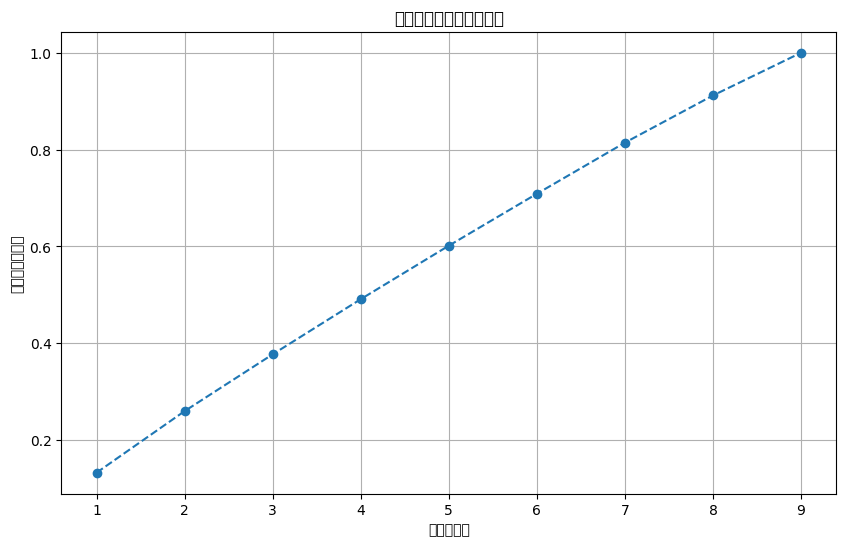


PCA 轉換後的數據前五行：


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9
0,-0.673765,-0.045497,0.098687,1.651609,1.518522,-0.734659,-1.235084,-0.568874,1.079633
1,0.992579,-2.465087,1.876166,-0.158912,1.089066,0.330267,-0.692078,-1.273423,-1.269243
2,-1.095959,0.868219,-0.238066,0.768459,-0.712055,1.296761,-0.542134,0.289728,0.413419
3,-0.889985,0.395271,-0.427217,1.102287,0.105092,0.605148,2.504148,0.196966,0.841571
4,-0.196250,0.651752,0.078478,-1.894818,-0.136002,-0.461122,-1.089968,1.511344,-1.065723


In [11]:
from sklearn.decomposition import PCA
import numpy as np

# 初始化 PCA 模型
# 我們先不指定 n_components，以便觀察所有主成分的解釋變異量
pca = PCA()

# 對標準化後的數據進行 PCA
X_pca = pca.fit_transform(X_scaled_df)

# 將 PCA 結果轉換回 DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])

print("數據已進行 PCA 轉換。")

# 顯示每個主成分解釋的變異量比例
print("\n每個主成分解釋的變異量比例：")
display(pca.explained_variance_ratio_)

# 顯示累積解釋變異量
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("\n累積解釋變異量：")
display(cumulative_variance)

# 繪製解釋變異量圖，幫助選擇主成分數量
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('解釋變異量與主成分數量')
plt.xlabel('主成分數量')
plt.ylabel('累積解釋變異量')
plt.grid(True)
plt.show()

# 顯示 PCA 轉換後的數據前五行
print("\nPCA 轉換後的數據前五行：")
display(X_pca_df.head())

### 數據劃分 (訓練集與測試集)

In [12]:
from sklearn.model_selection import train_test_split

# 選擇保留的主成分數量，例如，如果我們希望保留大約 90% 的變異量，從圖中看大約需要 8 個主成分
# 您可以根據之前的累積解釋變異量圖來決定這個數字
n_components_to_retain = 8 # 根據累積解釋變異量圖，保留8個主成分可以達到約 91% 的變異量

# 選擇保留的主成分
X_final = X_pca_df.iloc[:, :n_components_to_retain]

# 將數據集劃分為訓練集和測試集
# test_size=0.2 表示 20% 的數據作為測試集
# random_state 確保每次運行劃分結果一致
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print(f"選擇保留 {n_components_to_retain} 個主成分進行後續分析。")
print(f"訓練集特徵形狀: {X_train.shape}")
print(f"測試集特徵形狀: {X_test.shape}")
print(f"訓練集目標變數形狀: {y_train.shape}")
print(f"測試集目標變數形狀: {y_test.shape}")

display(X_train.head())

選擇保留 8 個主成分進行後續分析。
訓練集特徵形狀: (2620, 8)
測試集特徵形狀: (656, 8)
訓練集目標變數形狀: (2620,)
測試集目標變數形狀: (656,)


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8
233,-0.036458,0.793940,0.186118,0.652500,-0.873666,-0.304703,-0.573694,-0.704301
831,0.641436,-1.227123,-0.800485,0.226943,0.981846,0.652883,-1.317676,0.860677
2658,0.712917,0.257700,-0.226899,-0.421664,1.396699,0.488677,0.471299,-0.432400
2495,-1.013385,-0.482055,-0.114524,-0.058091,0.038331,1.285329,-1.946156,0.428505
2603,-0.157861,-0.594982,0.268746,-0.383695,-0.311497,0.644224,0.852103,-0.267891
